# Предобработка набора данных

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    cohen_kappa_score
)

from google.colab import files

In [3]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_excel(filename)

df[['id', 'score', 'score_q1', 'score_q2', 'score_q3', 'time_q1', 'time_q2', 'time_q3', 'attendance', 'cheated']].head(10)

Saving ISIT.xlsx to ISIT (1).xlsx


,id,score,score_q1,score_q2,score_q3,time_q1,time_q2,time_q3,attendance,cheated
0,1,"0,00",0,0,0,0,0,0,1,0
1,2,"1,67",1,0,0,7,0,0,0,0
2,3,"1,67",1,0,0,6,0,0,1,0
3,4,"0,00",0,0,0,0,0,0,1,0
4,5,"0,00",0,0,0,0,0,0,1,0
5,6,"5,00",1,1,0,3,3,2,0,1
6,7,"10,00",1,1,1,2,4,7,1,1
7,8,"8,33",0,1,1,8,3,3,0,1
8,9,"0,00",0,0,0,0,0,0,1,0
9,10,"3,33",0,1,0,13,8,0,0,0


In [54]:
def prepare_question_level_data(df):
    data = []

    for _, row in df.iterrows():

        for q in [1, 2, 3]:

            score = row[f"score_q{q}"]

            if score != 0:
                data.append({
                    "id": row["id"],
                    "question": q,
                    "score": score,
                    "time": row[f"time_q{q}"],
                    "attendance": row["attendance"],
                    "avg_time": df[df[f"score_q{q}"] == 1][f"time_q{q}"].mean(),
                    "cheated": row["cheated"] == 1
                })

    result = pd.DataFrame(data)

    result = result.astype({
        "id": "int64",
        "question": "int64",
        "score": "int64",
        "time": "int64",
        "attendance": "int64",
        "cheated": "bool"
    })

    return result

In [5]:
data = prepare_question_level_data(df)

data.head(10)

,id,question,score,time,attendance,avg_time,cheated
0,2,1,1,7,0,5.882353,False
1,3,1,1,6,1,5.882353,False
2,6,1,1,3,0,5.882353,True
3,6,2,1,3,0,7.235294,True
4,7,1,1,2,1,5.882353,True
5,7,2,1,4,1,7.235294,True
6,7,3,1,7,1,9.826087,True
7,8,2,1,3,0,7.235294,True
8,8,3,1,3,0,9.826087,True
9,10,2,1,8,0,7.235294,False


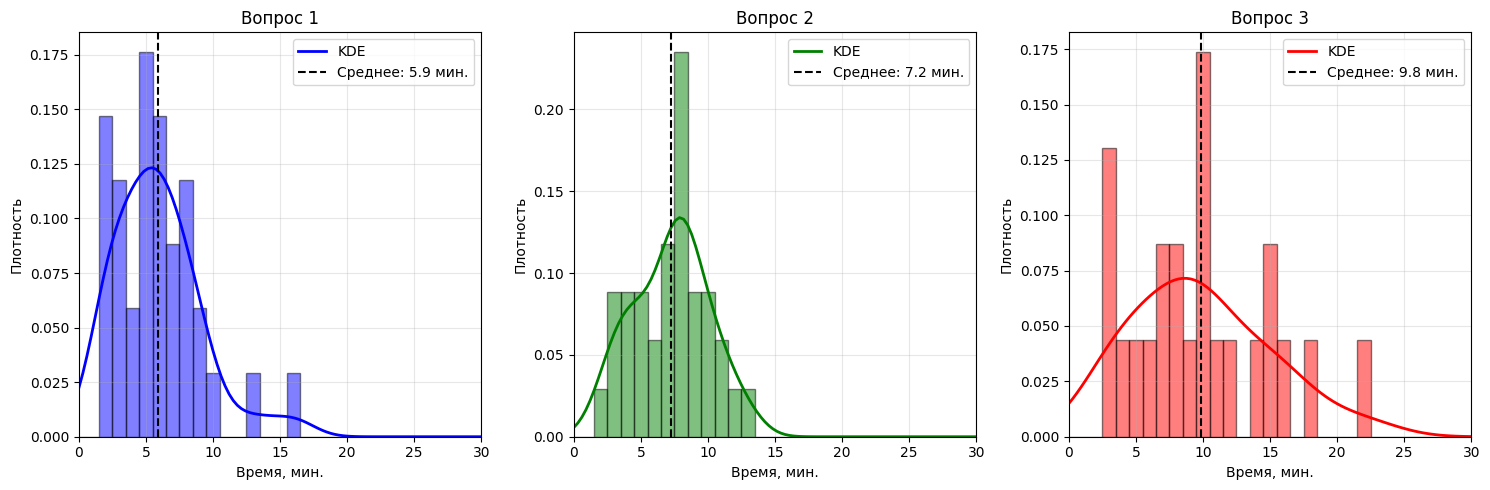

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['blue', 'green', 'red']
titles = ['Вопрос 1', 'Вопрос 2', 'Вопрос 3']

for i, (ax, color, title) in enumerate(zip(axes, colors, titles)):
    filtered_data = data[data["question"] == i + 1]['time']

    ax.hist(filtered_data, bins=range(0, 32, 1),
            edgecolor='black', alpha=0.5, color=color, align='left', density=True)

    kde = stats.gaussian_kde(filtered_data)
    x_range = np.linspace(0, 30, 100)
    ax.plot(x_range, kde(x_range), color=color, linewidth=2, label='KDE')

    mean_time = filtered_data.mean()
    ax.axvline(mean_time, color='black', linestyle='--', linewidth=1.5,
               label=f'Среднее: {mean_time:.1f} мин.')

    ax.set_xlabel('Время, мин.')
    ax.set_ylabel('Плотность')
    ax.set_title(title)
    ax.set_xticks(range(0, 31, 5))
    ax.set_xlim(0, 30)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

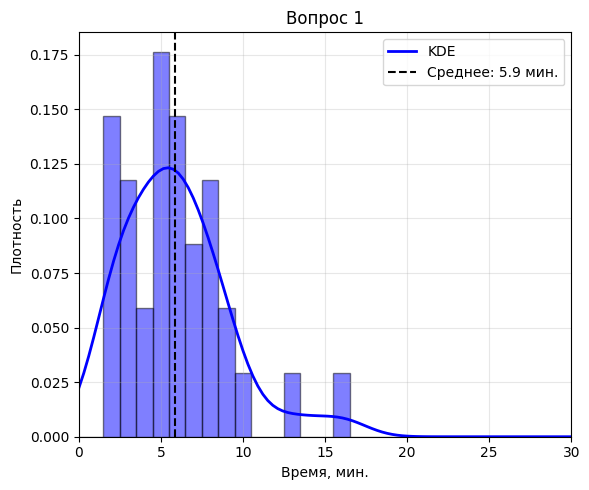

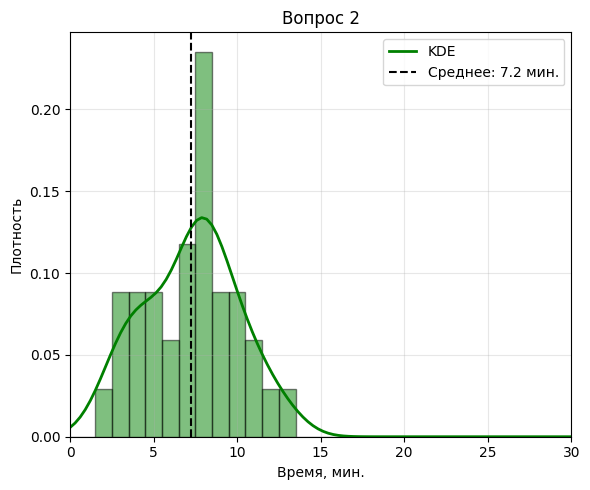

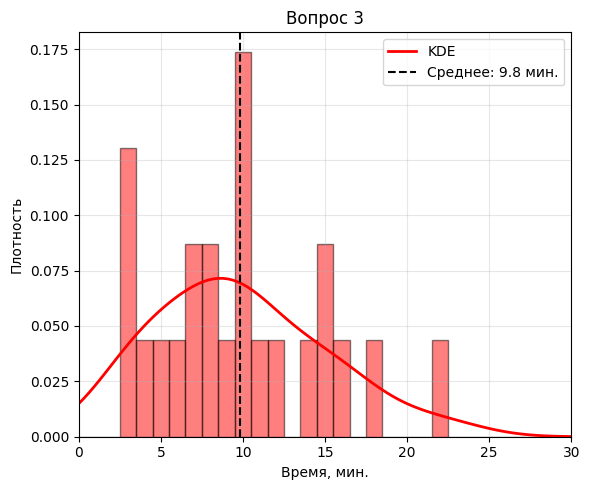

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

colors = ['blue', 'green', 'red']
titles = ['Вопрос 1', 'Вопрос 2', 'Вопрос 3']

for i, (color, title) in enumerate(zip(colors, titles)):
    filtered_data = data[data["question"] == i + 1]['time']

    fig, ax = plt.subplots(figsize=(6, 5))

    ax.hist(
        filtered_data,
        bins=range(0, 32, 1),
        edgecolor='black',
        alpha=0.5,
        color=color,
        align='left',
        density=True
    )

    kde = stats.gaussian_kde(filtered_data)
    x_range = np.linspace(0, 30, 100)
    ax.plot(x_range, kde(x_range), color=color, linewidth=2, label='KDE')

    mean_time = filtered_data.mean()
    ax.axvline(
        mean_time,
        color='black',
        linestyle='--',
        linewidth=1.5,
        label=f'Среднее: {mean_time:.1f} мин.'
    )

    ax.set_xlabel('Время, мин.')
    ax.set_ylabel('Плотность')
    ax.set_title(title)
    ax.set_xticks(range(0, 31, 5))
    ax.set_xlim(0, 30)
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()

    plt.savefig(f'question_{i+1}.png', dpi=300, bbox_inches='tight')

    plt.show()

In [8]:
import numpy as np
import pandas as pd
from scipy import stats

for i in range(1, 4):

    filtered_data = data[data["question"] == i]['time'].dropna()

    mu = filtered_data.mean()
    sigma = filtered_data.std(ddof=1)

    bins = np.linspace(filtered_data.min(),
                       filtered_data.max(),
                       6)

    observed, _ = np.histogram(filtered_data, bins=bins)
    expected_probs = []

    for j in range(len(bins)-1):
        p = stats.norm.cdf(bins[j+1], mu, sigma) - \
            stats.norm.cdf(bins[j], mu, sigma)
        expected_probs.append(p)

    expected = np.array(expected_probs) * len(filtered_data)

    chi2_stat = ((observed - expected) ** 2 / expected).sum()
    df = 5 - 1 - 2

    p_value = 1 - stats.chi2.cdf(chi2_stat, df)

    print(f'\nВопрос {i}')
    print('Наблюдаемые:', observed)
    print('Ожидаемые :', np.round(expected, 2))
    print(f'χ² = {chi2_stat:.3f}')
    print(f'p-value = {p_value:.5f}')

    if p_value > 0.05:
        print('Нет оснований отвергнуть нормальность')
    else:
        print('Нормальность отвергается')


Вопрос 1
Наблюдаемые: [11 14  7  1  1]
Ожидаемые : [ 8.71 11.55  7.37  2.26  0.33]
χ² = 3.190
p-value = 0.20294
Нет оснований отвергнуть нормальность

Вопрос 2
Наблюдаемые: [ 7  5 12  6  4]
Ожидаемые : [ 3.64  8.34 10.47  7.21  2.72]
χ² = 5.472
p-value = 0.06484
Нет оснований отвергнуть нормальность

Вопрос 3
Наблюдаемые: [6 9 3 4 1]
Ожидаемые : [4.28 6.56 5.89 3.09 0.95]
χ² = 3.281
p-value = 0.19393
Нет оснований отвергнуть нормальность


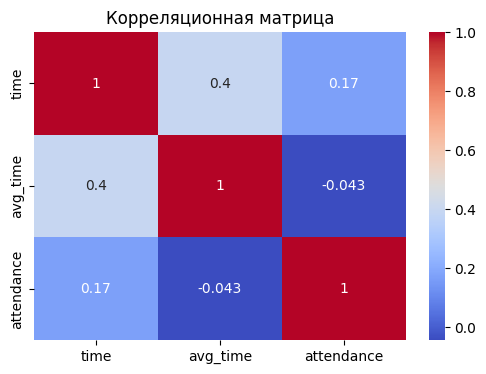

In [9]:
corr_matrix = data[["time", "avg_time", "attendance"]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Корреляционная матрица")
plt.show()

In [10]:
X = data[["time", "avg_time", "attendance"]]

X_const = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

      feature       VIF
0        time  5.737663
1    avg_time  5.583813
2  attendance  1.552845


In [11]:
X = data[
    ["time", "avg_time", "attendance"]
]

y = data["cheated"].astype(int)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=22
)

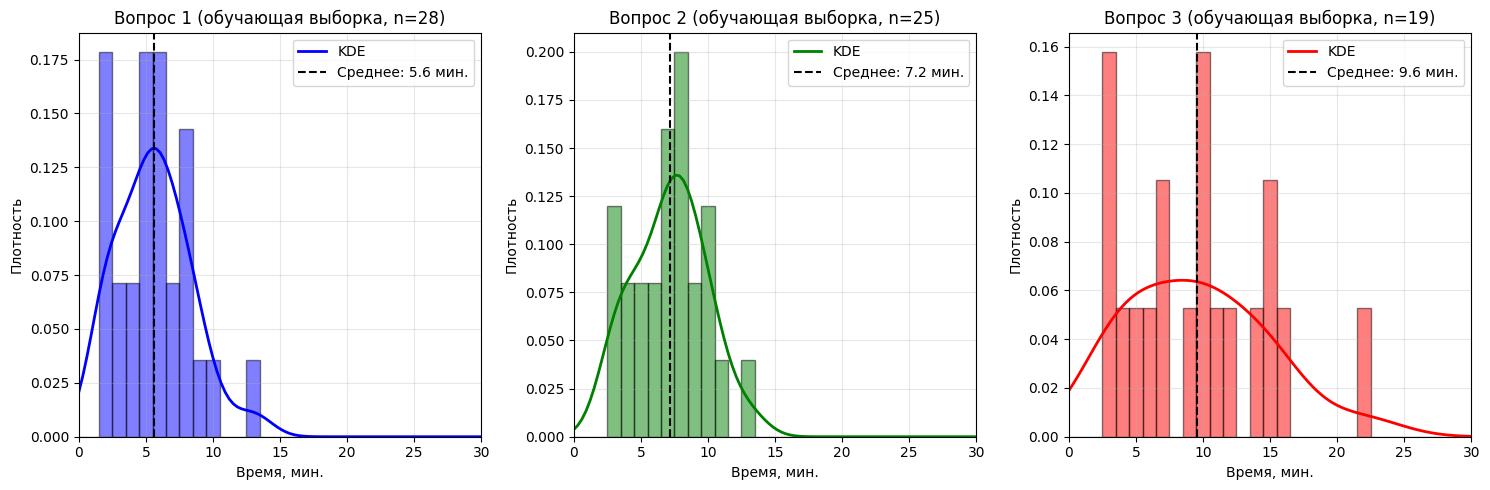

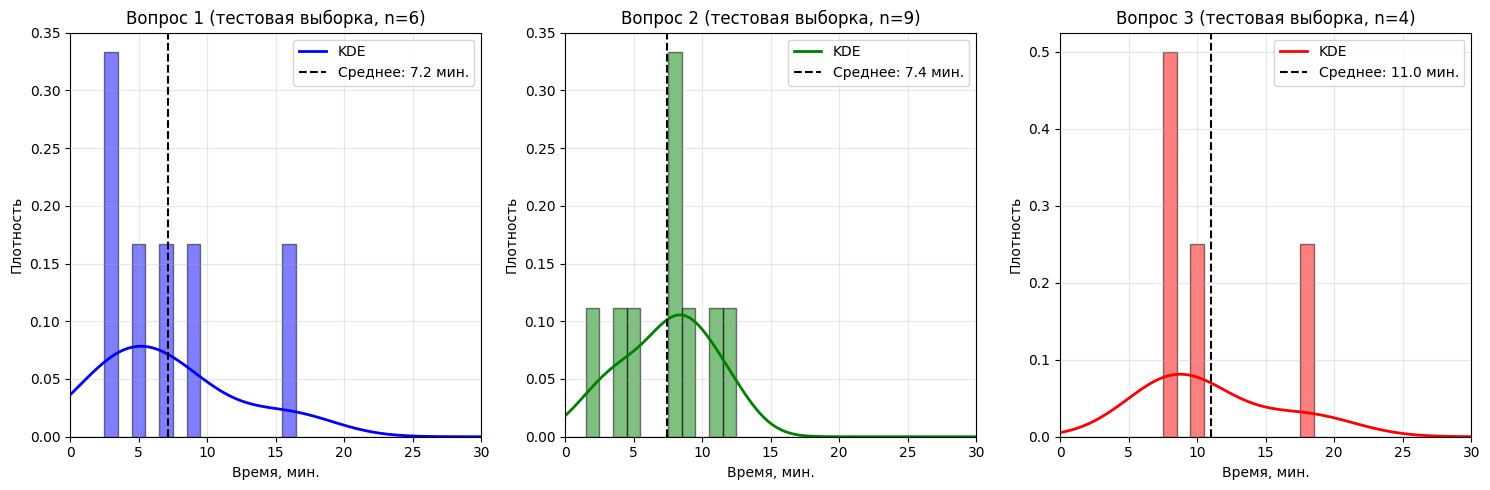

In [20]:
train_data = data.loc[X_train.index].copy()
test_data = data.loc[X_test.index].copy()

# Training set

fig_train, axes_train = plt.subplots(1, 3, figsize=(15, 5))

colors = ['blue', 'green', 'red']
titles = ['Вопрос 1', 'Вопрос 2', 'Вопрос 3']

for i, (ax, color, title) in enumerate(zip(axes_train, colors, titles)):
    filtered_data = train_data[train_data["question"] == i + 1]['time']

    if len(filtered_data) > 0:
        ax.hist(filtered_data, bins=range(0, 32, 1),
                edgecolor='black', alpha=0.5, color=color, align='left', density=True)

        kde = stats.gaussian_kde(filtered_data)
        x_range = np.linspace(0, 30, 100)
        ax.plot(x_range, kde(x_range), color=color, linewidth=2, label='KDE')

        mean_time = filtered_data.mean()
        ax.axvline(mean_time, color='black', linestyle='--', linewidth=1.5,
                   label=f'Среднее: {mean_time:.1f} мин.')

    ax.set_xlabel('Время, мин.')
    ax.set_ylabel('Плотность')
    ax.set_title(f'{title} (обучающая выборка, n={len(filtered_data)})')
    ax.set_xticks(range(0, 31, 5))
    ax.set_xlim(0, 30)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# Test set

fig_test, axes_test = plt.subplots(1, 3, figsize=(15, 5))

for i, (ax, color, title) in enumerate(zip(axes_test, colors, titles)):
    filtered_data = test_data[test_data["question"] == i + 1]['time']

    if len(filtered_data) > 0:
        ax.hist(filtered_data, bins=range(0, 32, 1),
                edgecolor='black', alpha=0.5, color=color, align='left', density=True)

        kde = stats.gaussian_kde(filtered_data)
        x_range = np.linspace(0, 30, 100)
        ax.plot(x_range, kde(x_range), color=color, linewidth=2, label='KDE')

        mean_time = filtered_data.mean()
        ax.axvline(mean_time, color='black', linestyle='--', linewidth=1.5,
                   label=f'Среднее: {mean_time:.1f} мин.')

    ax.set_xlabel('Время, мин.')
    ax.set_ylabel('Плотность')
    ax.set_title(f'{title} (тестовая выборка, n={len(filtered_data)})')
    ax.set_xticks(range(0, 31, 5))
    ax.set_xlim(0, 30)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# Построение регрессионных моделей

In [24]:
X_mod = X.copy()

avg_time = X_mod["time"].mean()
X_mod["time_rel"] = (X_mod["time"] - avg_time) / avg_time

X_mod = X_mod.drop(columns=["time"])

In [69]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_train = lin_model.predict(X_train)
y_pred_test = lin_model.predict(X_test)

coef_table = pd.DataFrame({
    "feature": X_mod.columns,
    "coef": lin_model.coef_
})

print("Коэффициенты линейной регрессии:\n")
print(coef_table)
print("\nIntercept:", lin_model.intercept_)

Коэффициенты линейной регрессии:

      feature      coef
0    avg_time  0.083535
1  attendance -0.053567
2    time_rel -0.510444

Intercept: -0.37190072390539164


In [68]:
rss = np.sum((y_test - y_pred_test) ** 2)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print("--- Линейная регрессия ---\n")
print("RSS:", rss)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 train:", r2_train)
print("R2 test:", r2_test)

--- Линейная регрессия ---

RSS: 2.0748111509931633
MSE: 0.10920058689437702
RMSE: 0.33045512084756234
R2 train: 0.38707834566517885
R2 test: 0.34297646885216504


In [67]:
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

log_model.fit(X_train, y_train)

y_pred_class = log_model.predict(X_test)
y_pred_proba = log_model.predict_proba(X_test)[:, 1]

log_coef = pd.DataFrame({
    "feature": X_mod.columns,
    "coef": log_model.coef_[0]
})

print("Коэффициенты логистической регрессии:\n")
print(log_coef)

Коэффициенты логистической регрессии:

      feature      coef
0    avg_time  0.410222
1  attendance -0.351306
2    time_rel -3.377076


In [66]:
accuracy = accuracy_score(y_test, y_pred_class)
precision = precision_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)
roc_auc = roc_auc_score(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred_class)

print("--- Логистическая регрессия ---\n")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)

--- Логистическая регрессия ---

Accuracy: 0.8421052631578947
Precision: 0.5714285714285714
Recall: 1.0
F1-score: 0.7272727272727273
ROC-AUC: 0.925


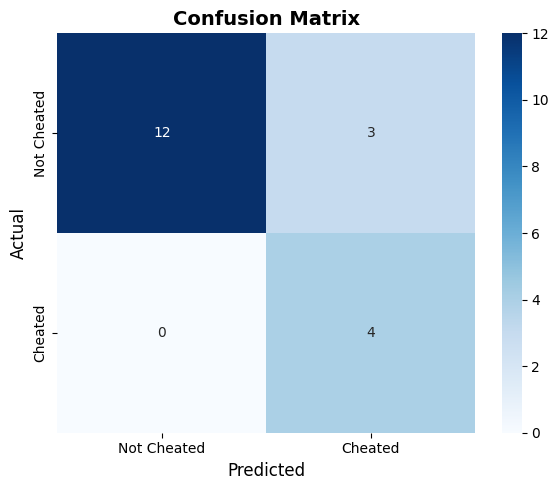

In [33]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Not Cheated', 'Cheated'],
            yticklabels=['Not Cheated', 'Cheated'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

# Исследование на дополнительном наборе

In [55]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]
new_df = pd.read_excel(filename)

Saving CB.xlsx to CB (6).xlsx


In [56]:
new_data = prepare_question_level_data(new_df)
new_data.head(10)

,id,question,score,time,attendance,avg_time,cheated
0,1,1,1,7,0,8.350000,True
1,1,2,1,5,0,8.230769,True
2,1,3,1,9,0,9.105263,True
3,2,1,1,12,1,8.350000,False
4,2,2,1,9,1,8.230769,False
5,2,3,1,8,1,9.105263,False
6,3,1,1,8,0,8.350000,True
7,3,2,1,6,0,8.230769,True
8,3,3,1,8,0,9.105263,True
9,4,1,1,5,0,8.350000,True


In [59]:
new_X = new_data[
    ["time", "avg_time", "attendance"]
].copy()
new_y = new_data["cheated"]

new_X["time_rel"] = (new_X["time"] - new_X["avg_time"]) / new_X["avg_time"]
new_X = new_X.drop(columns=["time"])

In [60]:
new_pred_lin = lin_model.predict(new_X)

rss_new = np.sum((new_y - new_pred_lin) ** 2)
mse_new = mean_squared_error(new_y, new_pred_lin)
rmse_new = np.sqrt(mse_new)
r2_new = r2_score(new_y, new_pred_lin)

print("--- Линейная регрессия на доп. наборе ---\n")
print("RSS:", rss_new)
print("MSE:", mse_new)
print("RMSE:", rmse_new)
print("R2:", r2_new)


--- Линейная регрессия на доп. наборе ---
RSS: 9.282486720656054
MSE: 0.12892342667577852
RMSE: 0.3590590852154817
R2: 0.21831690773422685


In [65]:
new_pred_class = log_model.predict(new_X)
new_pred_proba = log_model.predict_proba(new_X)[:, 1]

accuracy_new = accuracy_score(new_y, new_pred_class)
precision_new = precision_score(new_y, new_pred_class)
recall_new = recall_score(new_y, new_pred_class)
f1_new = f1_score(new_y, new_pred_class)
roc_auc_new = roc_auc_score(new_y, new_pred_proba)
cm_new = confusion_matrix(new_y, new_pred_class)

print("--- Логистическая регрессия на доп. наборе ---\n")
print("Accuracy:", accuracy_new)
print("Precision:", precision_new)
print("Recall:", recall_new)
print("F1-score:", f1_new)
print("ROC-AUC:", roc_auc_new)

---Логистическая регрессия на доп. наборе---

Accuracy: 0.8055555555555556
Precision: 0.52
Recall: 0.8666666666666667
F1-score: 0.65
ROC-AUC: 0.9269005847953217


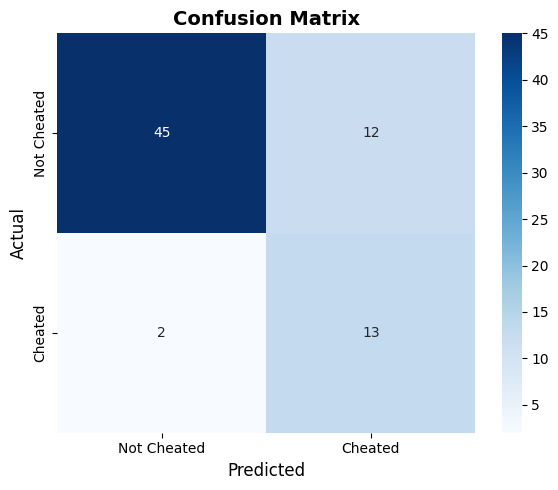

In [63]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Not Cheated', 'Cheated'],
            yticklabels=['Not Cheated', 'Cheated'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()